# Programming Longer Code

*Cynthia was still trying to write the program that would decode where she should go next.  Sweat started to bead on her forehead.*

<i>"This doesn't need to be a big deal," she told herself.  "Just design top-down, and test from the bottom-up.  Easy!"</i>

There's a lot to know about the details of programming, such as what each keyword does and how loops work.  But there's also a process to programming, which becomes especially important as you write longer pieces of code.

This lecture is about tips for programming code that runs longer than a short snippet.

*Note:  Because we're showing a programming process, not all these code cells are meant to be run!  Just the ones labeled RUNNABLE!*

It may help in this lecture to understand *precision*, *recall*, and *F-measure*, which are metrics for evaluating machine learning classifiers.

*Precision* is the proportion of examples labeled "yes" that are really "yes".  In a spam classifier, if 10 emails were labeled spam but only 5 were really spam, precision is 0.5.

*Recall* is the proportion of true examples that were found.  If there were 20 spam emails in the dataset and 10 were correctly labeled, recall is 0.5.

*F-measure* combines precision and recall into a single metric.  If precision is 0.5 and recall is 0.5, F-measure is 0.5.

Remembering these definitions isn't strictly necessary, but I thought you might want to know what the example is about.

<img src=" 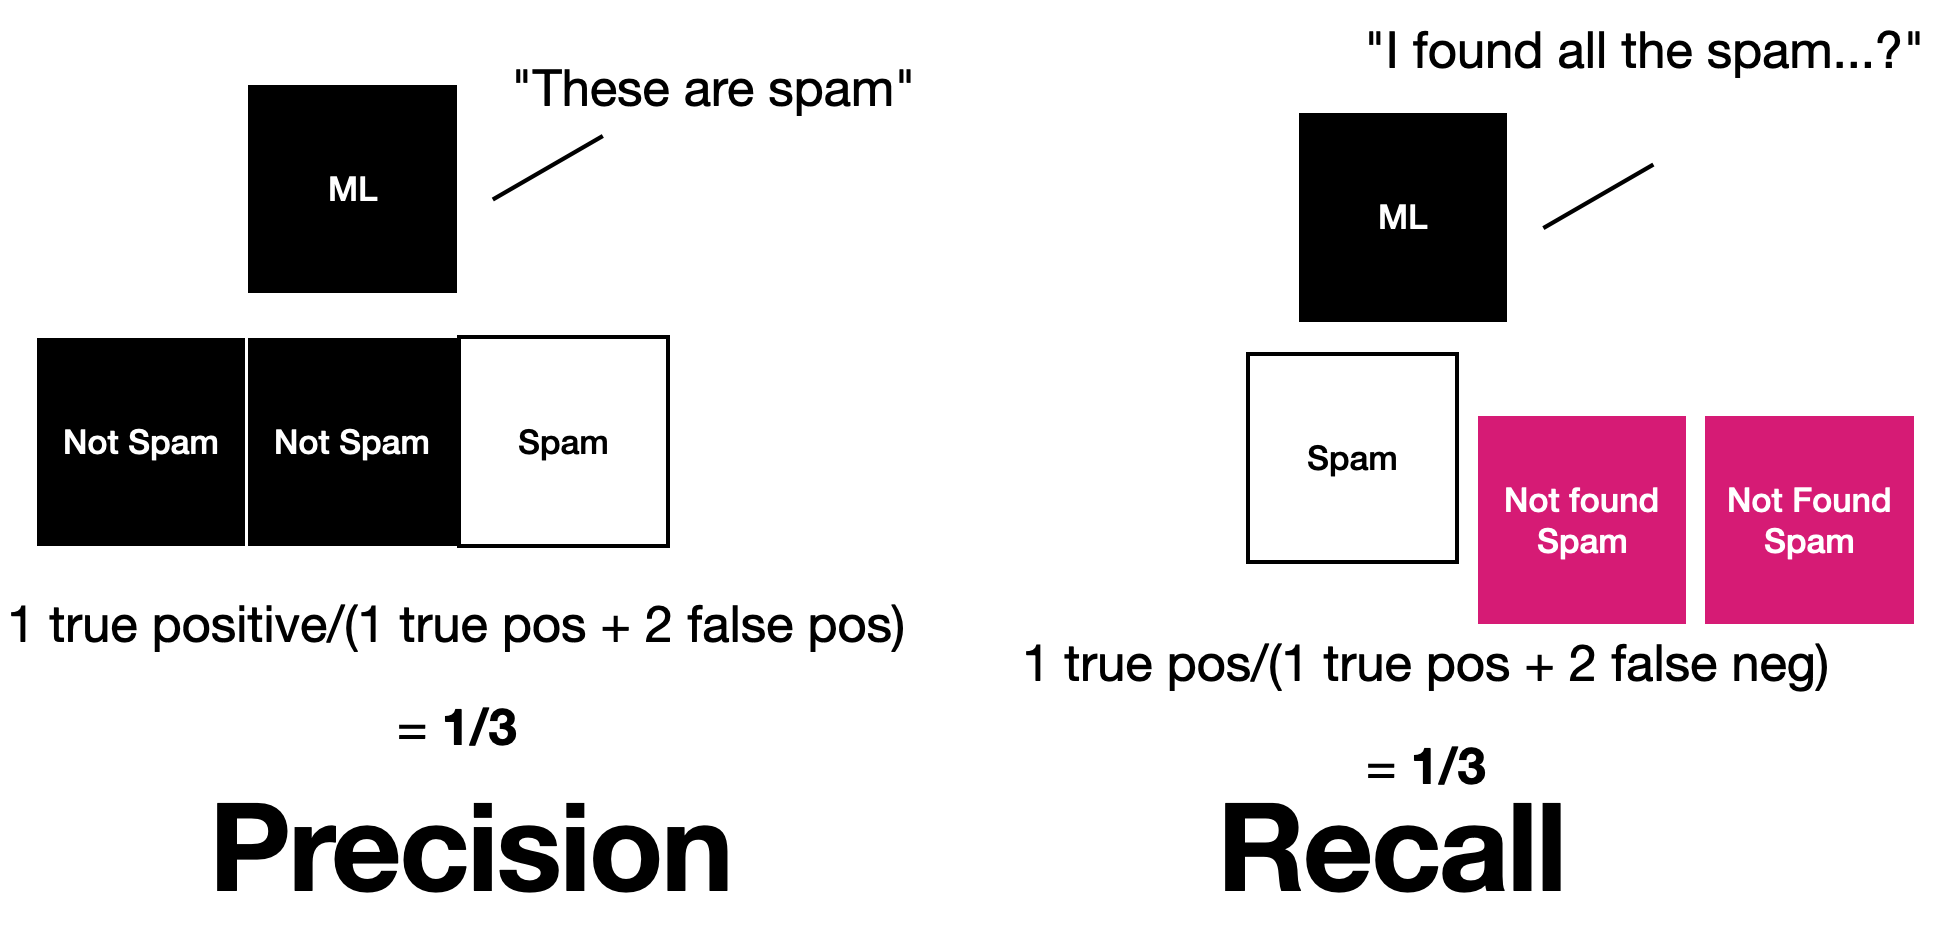">

*Write a function that, given a list of tuples of the form (tp, fp, tn, fn), returns a list of F-measures computed from those tuples.  The F-measure is (2 * precision * recall)/(precision + recall), the precision is tp/(tp + fp), and the recall is tp/(tp + fn).*

This function honestly won't be that long, but it has just enough complexity to potentially seem overwhelming at first to a new programmer.  Where do you start?  We'll break it down.

# Pseudocode

Recall from the functions lecture that outlining code in pseudocode first can be a good way to start, so that time isn't wasted writing unnecessary code.

In [ ]:
# f-measures

# for each tuple:
#    compute the f-measure of that tuple

"Computing the f-measure" sounds like something a function would do, so, we'll pseudocode that function, too.

In [ ]:
# f-measure
#
# calculate precision
# calculate recall
# return (2 * precision * recall)/(precision +recall)

We could further define functions for precision and recall, but let's be realistic - programmers don't always define functions when they could.  So let's stick with this as our sketch.

# Function comments

Besides making your code more readable to others, function comments have the nice effect of clarifying to yourself what your function ought to be doing, before you start programming.  Sometimes in the process of writing comments, you end up changing your design a little.

Now is the time to decide what each function takes as arguments and returns, and the types of each.  You can always go back later if you realize you omitted something, but this will help keep you from getting confused as you write.

In [ ]:
# f_measures
    """
    Compute f-measure for each item in a list.
    
    Argument: stats_list (list):  a list of tuples of four ints, (tp, fp, tn, fn)
               (these stand for true positive, false positive, etc)
    Returns:  a list of floats, the f-measures.
    """
#   for each tuple:
#       compute the f-measure of that tuple

# f_measure
    """
    Compute the f-measure, a performance measure that ignores true negatives.
    
    Arguments:  tp (int):  the count of true positives
                fp (int):  the count of false negatives
                tn (int):  the count of true negatives
                fn (int):  the count of false negatives
    Returns: a float, the f-measure.
    """
#
#     calculate precision
#     calculate recall
#     return (2 * precision * recall)/(precision +recall)

Like pseudocode, this step can conceivably be skipped.  Many employers would prefer to have the comments, though, and if you have to or want to, this is the time to write them.

# Review Break:  Choosing a type of iteration

Some types of iteration we've seen - when might you use each?

* Plain "for" loop over iterable
* "For" loop with range()
* while loop
* nested loop
* list comprehension

(see solution notebook)

Which *two* methods of iteration would be appropriate for f-measures?

When is it good to be "fancy"?  Consider your audience - who's going to read your code?  And consider yourself - will your code confuse you later?

In [ ]:
def f_measures(stats_list):
    """
    Compute f-measure for each item in a list.
    
    Argument: stats_list (list):  a list of tuples of four ints, (tp, fp, tn, fn)
               (these stand for true positive, false positive, etc)
    Returns:  a list of floats, the f-measures.
    """
    for tp, fp, tn, fn in stats_list:
        f = f_measure(tp, fp, tn, fn)

At this point, we might notice that something was missing from our pseudocode - the code we've written has no return value.  But we can correct this oversight as we're writing.

In [ ]:
def f_measures(stats_list):
    """
    Compute f-measure for each item in a list.
    
    Argument: stats_list (list):  a list of tuples of four ints, (tp, fp, tn, fn)
               (these stand for true positive, false positive, etc)
    Returns:  a list of floats, the f-measures.
    """
    out = []
    for tp, fp, tn, fn in stats_list:
        f = f_measure(tp, fp, tn, fn)
        out.append(f)
    return f

## Review break

* We could have generated a *set* of f-measures.  Why didn't we?

* Are there circumstances where we'd want an *array* of f-measures?

(see solution notebook)

# Tests

Let's just briefly finish up a first pass at the rest of the code.

In [ ]:
# RUNNABLE!
def f_measure(tp, fp, tn, fn):
    """
    Compute the f-measure, a performance measure that ignores true negatives.
    
    Arguments:  tp (int):  the count of true positives
                fp (int):  the count of false negatives
                tn (int):  the count of true negatives
                fn (int):  the count of false negatives
    Returns: a float, the f-measure.
    """
    precision = tp/(tp + fp)
    recall = tp/(tp + fn)
    return (2 * precision * recall)/(precision + recall)

Now our program is done ... but, we have no confidence that it works.  So we want to write tests.

And, here's where our decision to not make precision and recall functions comes to haunt us.  Because f-measure is complicated, and I can't easily figure out what f-measure I should expect given some tuples.  So I'm actually going to refactor this *just* so I can write some more intuitive tests.

In [ ]:
# RUNNABLE!
def f_measure(precision, recall):
    """
    Compute the f-measure, a performance measure that ignores true negatives.
    
    Arguments:  precision (float):  proportion of positive classifications that are correct
                recall (float):  proportion of positive examples that were found
    Returns: a float, the f-measure.
    """
    return (2 * precision * recall)/(precision + recall)

def precision(tp, fp):
    return tp/(tp + fp)

def recall(tp, fn):
    tp/(tp + fn)
    
def f_measures(stats_list):
    """
    Compute f-measure for each item in a list.
    
    Argument: stats_list (list):  a list of tuples of four ints, (tp, fp, tn, fn)
               (these stand for true positive, false positive, etc)
    Returns:  a list of floats, the f-measures.
    """
    out = []
    for tp, fp, tn, fn in stats_list:
        f = f_measure(precision(tp, fp), recall(tp, fn))
        out.append(f)
    return f

print(precision(4,4)) # Expect 0.5
print(recall(4,4)) # Expect 0.5
print(f_measure(1, 1)) # Expect 1

Well, that's strange.  "None"?

# Debugging

Recall from an earlier lecture that we can insert print() statements to get a better sense of what's wrong.

In [ ]:
# RUNNABLE!
def recall(tp, fn):
    print(tp/(tp + fn))
    
recall(4,4)

Okay, strange.  Now recall() seems to be working?

But wait, it only printed once.  That must be from the print() call.  So why would it not print the function's return value...

...Unless the function was returning None, because we forgot to include a return statement.

In [ ]:
# RUNNABLE!
def recall(tp, fn):
    print(tp/(tp + fn))
    return tp/(tp + fn)
    
recall(4,4)

In [ ]:
# RUNNABLE!
def f_measure(precision, recall):
    """
    Compute the f-measure, a performance measure that ignores true negatives.
    
    Arguments:  precision (float):  proportion of positive classifications that are correct
                recall (float):  proportion of positive examples that were found
    Returns: a float, the f-measure.
    """
    return (2 * precision * recall)/(precision + recall)

def precision(tp, fp):
    return tp/(tp + fp)

def recall(tp, fn):
    return tp/(tp + fn)
    
def f_measures(stats_list):
    """
    Compute f-measure for each item in a list.
    
    Argument: stats_list (list):  a list of tuples of four ints, (tp, fp, tn, fn)
               (these stand for true positive, false positive, etc)
    Returns:  a list of floats, the f-measures.
    """
    out = []
    for tp, fp, tn, fn in stats_list:
        f = f_measure(precision(tp, fp), recall(tp, fn))
        out.append(f)
    return f

print(precision(4,4)) # Expect 0.5
print(recall(4,4)) # Expect 0.5
print(f_measure(1, 1)) # Expect 1

# Corner cases

Once your tests for normal cases are working, you'll want to test extreme cases.  These "corner cases" should test the extreme values of the inputs, giving you confidence that even in rare circumstances, the function will continue to work.

In [ ]:
# RUNNABLE!
print(precision(0, 4)) # Expect 0
print(precision(0, 0)) # Expect ... oh, I guess we didn't think about this.  0?
print(precision(4, 0)) # Expect 1
print(recall(0, 4)) # Expect 0
print(recall(0, 0)) # Similarly to precision, let's return 0
print(recall(4, 0)) # Expect 1
print(f_measure(0, 0)) # Expect 0
print(f_measure(0.5, 0.5)) # Expect 0.5

Our tests thus forced us to think about cases that we weren't thinking about before.  Note that some programming styles recommend writing the tests first, which would save us the trouble of rewriting code to handle corner cases.  But we think that it's tough to even know what functions need testing, until you write the code.

In [ ]:
# RUNNABLE!
def f_measure(precision, recall):
    """
    Compute the f-measure, a performance measure that ignores true negatives.
    
    Arguments:  precision (float):  proportion of positive classifications that are correct
                recall (float):  proportion of positive examples that were found
    Returns: a float, the f-measure.
    """
    return (2 * precision * recall)/(precision + recall)

def precision(tp, fp):
    if tp + fp == 0:
        return 0
    return tp/(tp + fp)

def recall(tp, fn):
    if tp + fn == 0:
        return 0
    return tp/(tp + fn)
    
def f_measures(stats_list):
    """
    Compute f-measure for each item in a list.
    
    Argument: stats_list (list):  a list of tuples of four ints, (tp, fp, tn, fn)
               (these stand for true positive, false positive, etc)
    Returns:  a list of floats, the f-measures.
    """
    out = []
    for tp, fp, tn, fn in stats_list:
        f = f_measure(precision(tp, fp), recall(tp, fn))
        out.append(f)
    return f

print(precision(4,4)) # Expect 0.5
print(recall(4,4)) # Expect 0.5
print(f_measure(1, 1)) # Expect 1
print(precision(0, 4)) # Expect 0
print(precision(0, 0)) # Expect 0
print(precision(4, 0)) # Expect 1
print(recall(0, 4)) # Expect 0
print(recall(0, 0)) # Similarly to precision, let's return 0
print(recall(4, 0)) # Expect 1
print(f_measure(0, 0)) # Expect 0
print(f_measure(0.5, 0.5)) # Expect 0.5

In [ ]:
# RUNNABLE!
def f_measure(precision, recall):
    """
    Compute the f-measure, a performance measure that ignores true negatives.
    
    Arguments:  precision (float):  proportion of positive classifications that are correct
                recall (float):  proportion of positive examples that were found
    Returns: a float, the f-measure.
    """
    if precision + recall == 0:
        return 0
    return (2 * precision * recall)/(precision + recall)

def precision(tp, fp):
    if tp + fp == 0:
        return 0
    return tp/(tp + fp)

def recall(tp, fn):
    if tp + fn == 0:
        return 0
    return tp/(tp + fn)
    
def f_measures(stats_list):
    """
    Compute f-measure for each item in a list.
    
    Argument: stats_list (list):  a list of tuples of four ints, (tp, fp, tn, fn)
               (these stand for true positive, false positive, etc)
    Returns:  a list of floats, the f-measures.
    """
    out = []
    for tp, fp, tn, fn in stats_list:
        f = f_measure(precision(tp, fp), recall(tp, fn))
        out.append(f)
    return f

print(precision(4,4)) # Expect 0.5
print(recall(4,4)) # Expect 0.5
print(f_measure(1, 1)) # Expect 1
print(precision(0, 4)) # Expect 0
print(precision(0, 0)) # Expect 0
print(precision(4, 0)) # Expect 1
print(recall(0, 4)) # Expect 0
print(recall(0, 0)) # Similarly to precision, let's return 0
print(recall(4, 0)) # Expect 1
print(f_measure(0, 0)) # Expect 0
print(f_measure(0.5, 0.5)) # Expect 0.5

So there's a sample development process for a larger program or notebook, designing top-down and testing bottom-up.

The strategies and tips in this lecture will become more natural with practice!